In [1]:
!nvidia-smi

Tue Jan 13 11:37:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


|   0  NVIDIA RTX A6000               Off |   00000000:01:00.0 Off |                  Off |
| 30%   27C    P8             21W /  300W |     816MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   1  NVIDIA RTX A6000               Off |   00000000:25:00.0 Off |                  Off |
| 30%   26C    P8             20W /  300W |       4MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+------------------------+----------------------+
|   2  NVIDIA RTX A6000               Off |   00000000:41:00.0 Off |                  Off |
| 30%   25C    P8             20W /  300W |       4MiB /  49140MiB |      0%      Default |
|                                         |                        |            

In [ ]:
# Uninstall the current TensorFlow version
# !pip uninstall -y tensorflow

# Install the desired TensorFlow version 2.15.1
# !pip install tensorflow[and-cuda]==2.15.1

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-01-13 11:38:09.907766: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-13 11:38:09.907862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-13 11:38:10.066468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-13 11:38:10.392501: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 11:38:18.367261: W tensorflow/compiler/tf2

TensorFlow version: 2.15.1
Num GPUs Available:  1


In [3]:
# View network framework
from tk_r_em import load_network
# select one of the available networks from [sfr_hrsem, sfr_lrsem, sfr_hrstem, sfr_lrstem, sfr_hrtem, sfr_lrtem]
net_name = 'sfr_lrtem'
r_em_nn = load_network(net_name)
r_em_nn.summary()

2026-01-13 11:38:49.592044: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46732 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


Model: "gen_"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_gen (InputLayer)      [(None, None, None, 1)]      0         []                            
                                                                                                  
 gen_r_em_pp (Custom>lay_r_  ((None, None, None, 1),      0         ['input_gen[0][0]']           
 em_pp)                       (None, 1, 1, 1),                                                    
                              (None, 1, 1, 1))                                                    
                                                                                                  
 gen_fst_0_conv (Conv2D)     (None, None, None, 64)       640       ['gen_r_em_pp[0][0]']         
                                                                                               

2026-01-13 11:39:17.813183: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


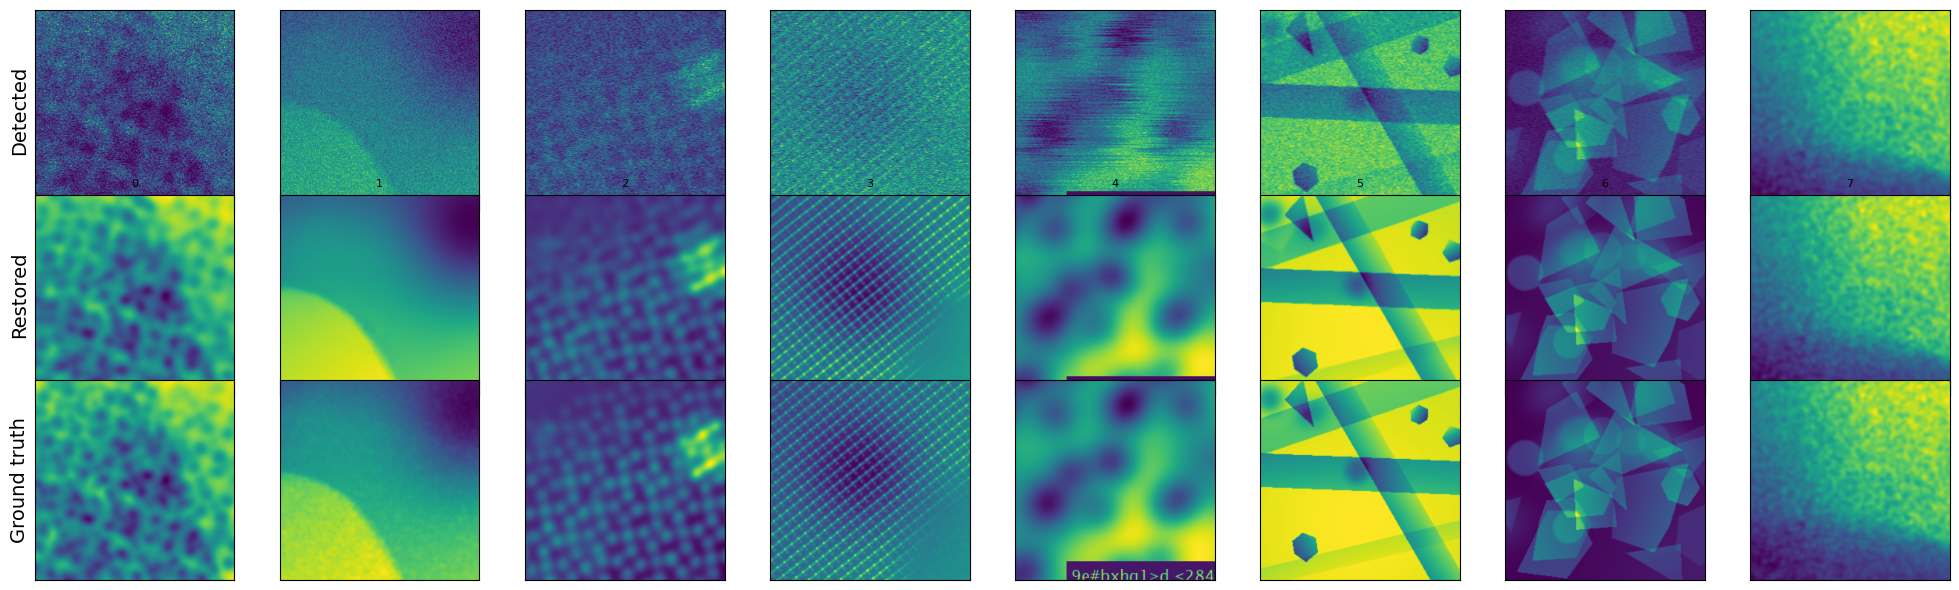

In [4]:
import matplotlib.pyplot as plt
from tk_r_em import load_network, load_sim_test_data

"""
Perform inference on test data using a pre-trained model and visualize the results.
"""
# select one of the available networks from [sfr_hrsem, sfr_lrsem, sfr_hrstem, sfr_lrstem, sfr_hrtem, sfr_lrtem]
net_name = 'sfr_lrsem'

# load its corresponding data
x, y = load_sim_test_data(net_name)

# load its corresponding model
r_em_nn = load_network(net_name)

n_data = x.shape[0]
batch_size = 8

# run inference
y_p = r_em_nn.predict(x, batch_size)

fig, axs = plt.subplots(3, n_data, figsize=(20, 6))

for ik in range(n_data):
    x_ik = x[ik, :, :, 0].squeeze()
    y_p_ik = y_p[ik, :, :, 0].squeeze()
    y_ik = y[ik, :, :, 0].squeeze()

    ir = 0
    axs[ir][ik].imshow(x_ik, cmap='viridis')
    axs[ir][ik].set_xticks([])
    axs[ir][ik].set_yticks([])
    axs[ir][ik].grid(False)

    if ik == 0:
        axs[ir][ik].set_ylabel(f"Detected", fontsize=14, )

    ir = 1
    axs[ir][ik].imshow(y_p_ik, cmap='viridis')
    axs[ir][ik].set_xticks([])
    axs[ir][ik].set_yticks([])
    axs[ir][ik].grid(False)

    if ik == 0:
        axs[ir][ik].set_ylabel(f"Restored", fontsize=14)
    axs[ir][ik].set_title(f'{ik}', fontsize=8)

    ir = 2
    axs[ir][ik].imshow(y_ik, cmap='viridis')
    axs[ir][ik].set_xticks([])
    axs[ir][ik].set_yticks([])
    axs[ir][ik].grid(False)

    if ik == 0:
        axs[ir][ik].set_ylabel(f"Ground truth", fontsize=14)

plt.subplots_adjust(hspace=2, wspace=10)
plt.tight_layout()

In [5]:
from tk_r_em import load_hrstem_exp_test_data

x_orig = load_hrstem_exp_test_data('exp_hrstem')
print(f"HxW: {x_orig.shape[2]}x{x_orig.shape[3]}") 

HxW: 768x1


In [16]:
import numpy as np
from PIL import Image

def file_reader_jpg(path):
    im = Image.open(path).convert("L")
    data = np.array(im, dtype=np.uint16)  
    
    return [{'data': data}]

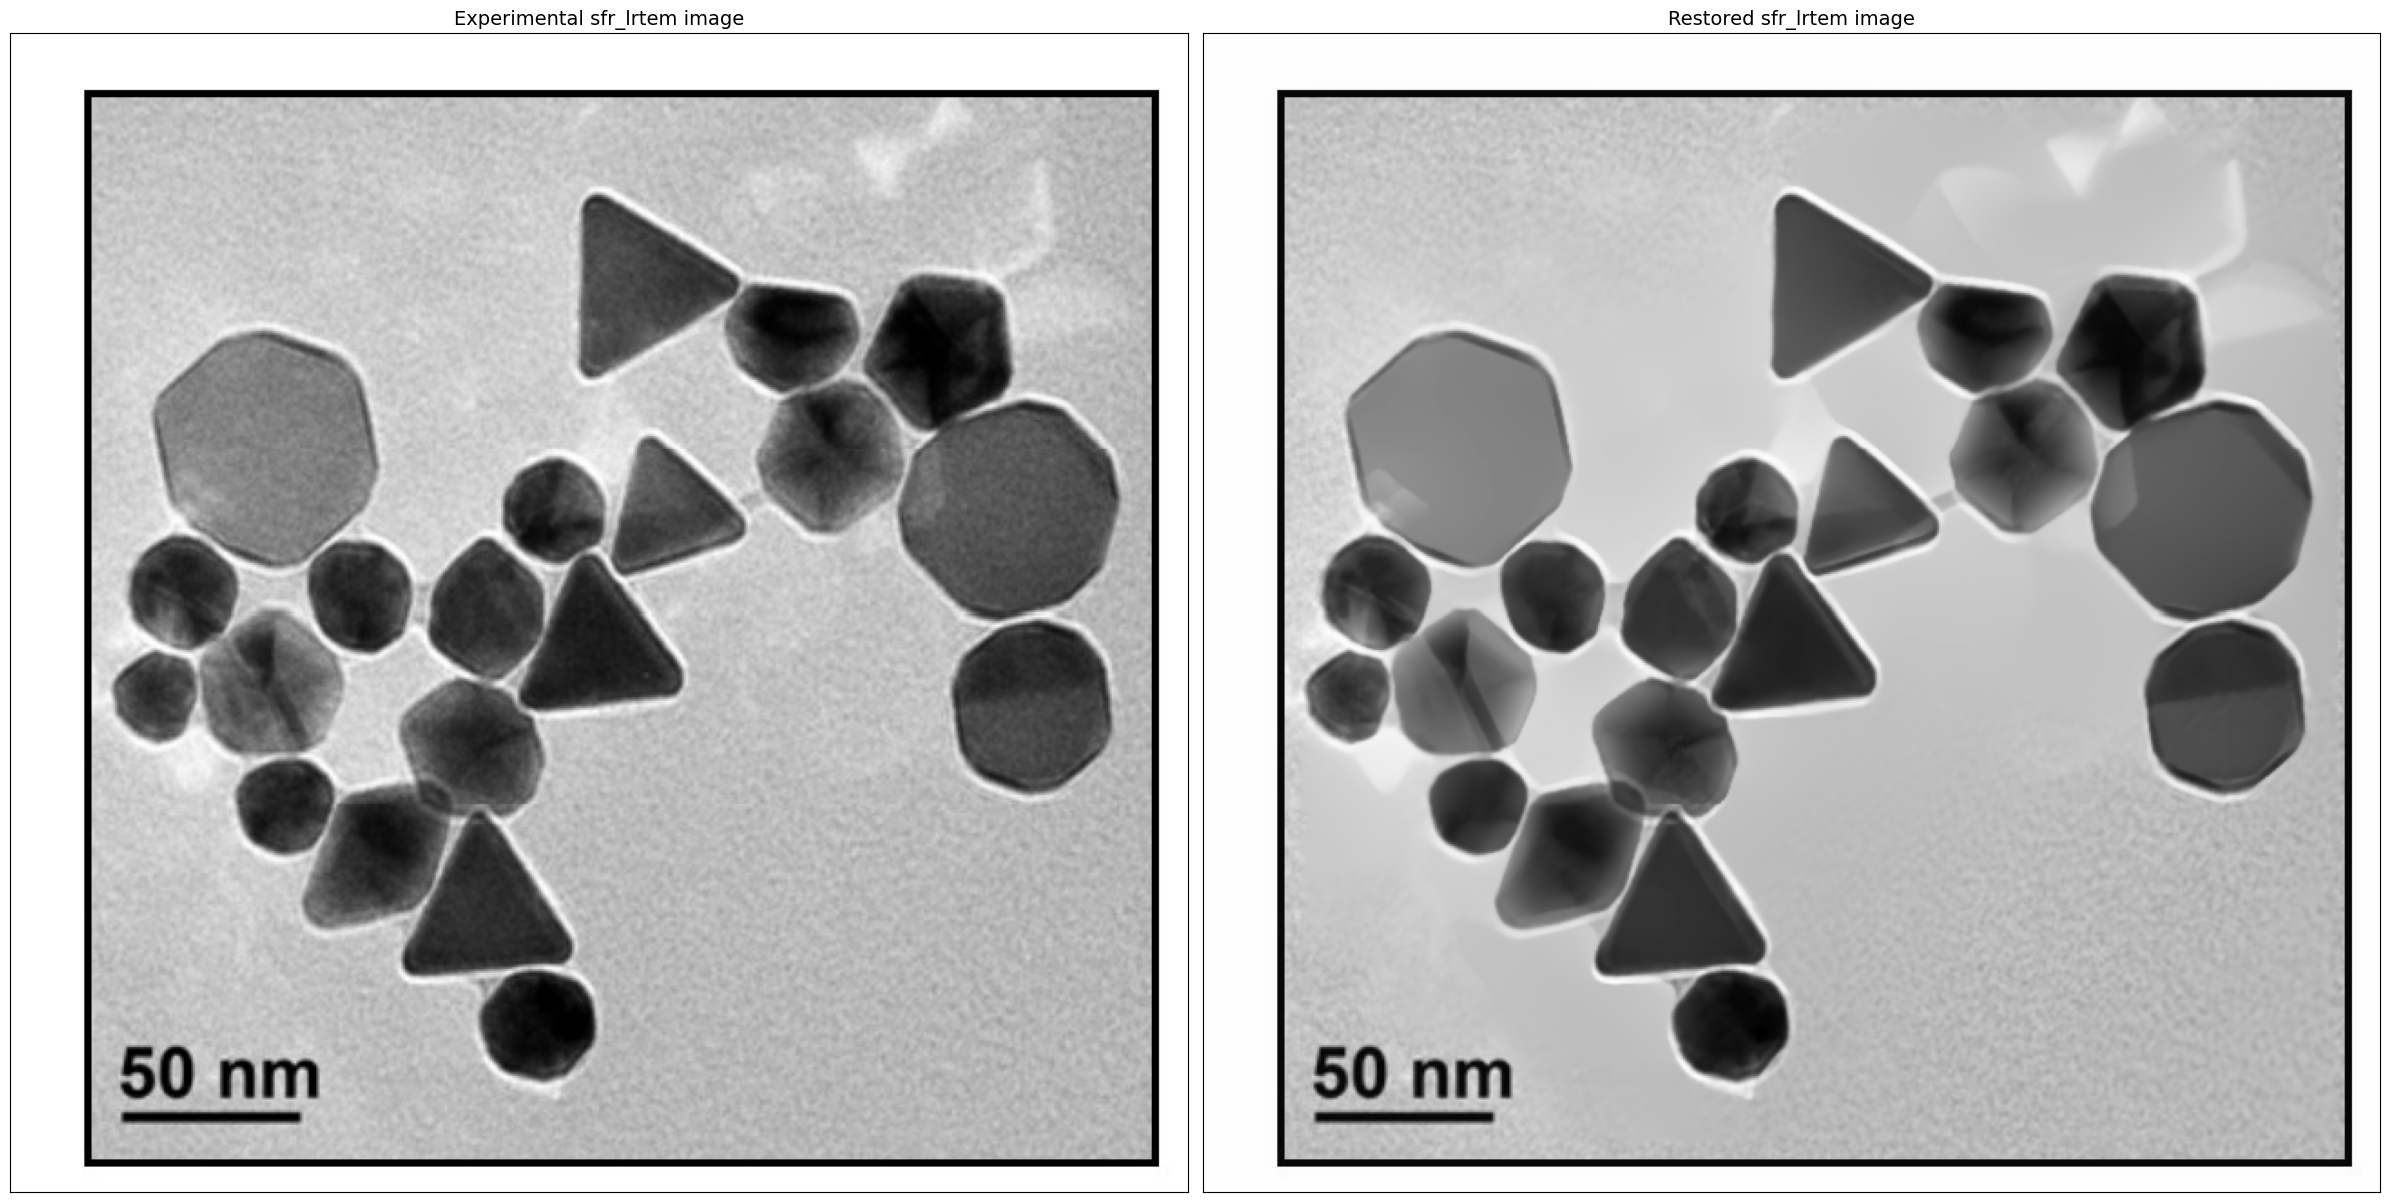

In [ ]:
from tk_r_em import load_network
import matplotlib.pyplot as plt
from rsciio.tia import file_reader
import numpy as np
import os

"""
Perform inference on test data using a pre-trained model and visualize the results.
"""
# select one of the available networks from [sfr_hrsem, sfr_lrsem, sfr_hrstem, sfr_lrstem, sfr_hrtem, sfr_lrtem]
net_name = 'sfr_lrtem'

# Use the current working directory as the root directory
root = os.getcwd()

# Example of constructing a path relative to the current working directory
path = '/mnt/tank/scratch/plutskyi/nanoshape/test_images/725.jpg'
    
x = file_reader_jpg(path)
x = np.array(x[0]['data'], np.float32)

# load its corresponding model
r_em_nn = load_network(net_name)
# r_em_nn.summary()

# run inference
y_p = r_em_nn.predict_patch_based(x, batch_size=4)

fig, axs = plt.subplots(1, 2, figsize=(24, 12))
ir = 0
axs[ir].imshow(x, cmap='gray')
axs[ir].set_xticks([])
axs[ir].set_yticks([])
axs[ir].grid(False)
axs[ir].set_title(f"Experimental {net_name} image", fontsize=14, )

ir = 1
axs[ir].imshow(y_p, cmap='gray')
axs[ir].set_xticks([])
axs[ir].set_yticks([])
axs[ir].grid(False)
axs[ir].set_title(f"Restored {net_name} image", fontsize=14)

plt.subplots_adjust(hspace=2, wspace=10)
plt.tight_layout()
plt.savefig(f"restored.png", format='png',dpi=600)
plt.show()

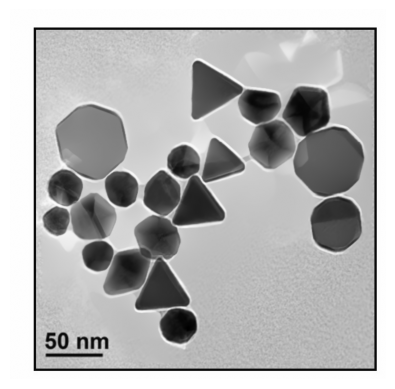

In [19]:
plt.imshow(y_p, cmap='gray')
plt.axis(False)
plt.show()